# 🔬 Experiment 4: VarMisuse — GAT vs GATv2

**Paper:** *How Attentive are Graph Attention Networks?* (Brody et al., 2022)

This notebook replicates the **VarMisuse** program analysis experiment. The task is to predict which variable fills a "slot" in a program's Abstract Syntax Tree (AST). The correct answer depends on deep semantic conditioning on the slot's context — a task that demands **dynamic attention**, which standard GAT cannot express.

### What We Expect
- **Standard GAT**: Struggles because its attention is static — for a given graph structure, the *ranking* of neighbor attention scores is the same regardless of which node is querying. Semantic disambiguation is impossible.
- **GATv2**: Should outperform GAT by dynamically conditioning attention on both the query (slot) and key (candidate) representations.

### Evaluation Protocol
Following the paper's inductive setup:
- Train on `graphs-train`, validate on `graphs-valid`, test on `graphs-test`
- The vocab is built only from the training set; OOV tokens map to `<UNK>`
- Metric: **Accuracy** — whether the highest-scoring candidate node is the correct one
- Each model uses node embeddings → GAT/GATv2 layers → slot + candidate node scoring

## 0. Environment Setup

In [1]:
# Mount Google Drive (shared data lives here)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.9 MB/s eta 0:00:00


In [3]:
!pip install ogb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 4.5 MB/s eta 0:00:00


In [4]:
# # Clone the repo into fast local Colab storage
# # !git clone https://github.com/anushka-vijay/gat-wrecked.git
# %cd gat-wrecked
# !pip install -r requirements.txt -q

# %load_ext autoreload
# %autoreload 2

In [5]:
import sys
sys.path.insert(0, '/content/gat-wrecked/src')

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


## 1. Configuration

Set the path to the VarMisuse `.zip` on your shared Drive and tune hyperparameters here.

In [6]:
import os

os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
# ─── PATH TO YOUR VARMISUSE ZIP ───────────────────────────────────────────────
# Update this to wherever the zip lives in your shared Drive
VARMISUSE_ZIP = '/content/drive/MyDrive/Colab Notebooks/gat-wrecked/GATv2_Datasets/datasets/graph-datasets.zip'
# ─── DATASET SIZES ────────────────────────────────────────────────────────────
# Reduce for quick smoke tests; increase for full replication
TRAIN_SIZE = 5000
VALID_SIZE = 1000
TEST_SIZE  = 1000

# ─── MODEL HYPERPARAMETERS ────────────────────────────────────────────────────
EMBEDDING_DIM  = 64    # Node type embedding dimension
HIDDEN_DIM     = 64   # GAT hidden channels
NUM_HEADS      = 4     # Attention heads per layer
NUM_LAYERS     = 2     # Number of GAT/GATv2 message-passing layers
DROPOUT        = 0.1

# ─── TRAINING HYPERPARAMETERS ─────────────────────────────────────────────────
BATCH_SIZE     = 16
LEARNING_RATE  = 1e-3
WEIGHT_DECAY   = 1e-4
NUM_EPOCHS     = 30
PATIENCE       = 7     # Early stopping patience (epochs)

# ─── REPRODUCIBILITY ─────────────────────────────────────────────────────────
SEED = 42

import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

print("✅ Config set.")

✅ Config set.


In [7]:
import sys, os

# The repo is already in Drive — no need to clone
# Add src/ to path so data_loaders.py is findable
sys.path.insert(0, '/content/drive/MyDrive/Colab Notebooks/gat-wrecked/src')

# Verify
print(os.listdir('/content/drive/MyDrive/Colab Notebooks/gat-wrecked/src'))

['utils.py', '__init__.py', 'train.py', 'models.py', 'data_loaders.py', '__pycache__']


## 2. Load Data

We build the vocabulary from the **training** split only, then pass it to the validation and test loaders. This enforces the inductive evaluation protocol — the model must generalize to unseen program structures.

In [8]:
from data_loaders import get_loader

# Build train loader + extract vocab
print("Loading TRAIN split...")
train_loader, train_dataset = get_loader(
    name='varmisuse',
    path=VARMISUSE_ZIP,
    batch_size=BATCH_SIZE,
    split='train',
    subset_size=TRAIN_SIZE
)
vocab = train_dataset.vocab
VOCAB_SIZE = len(vocab)
print(f"\nVocab size (from training data): {VOCAB_SIZE}")

# Pass the frozen train vocab to valid/test
print("\nLoading VALID split...")
valid_loader, _ = get_loader(
    name='varmisuse',
    path=VARMISUSE_ZIP,
    batch_size=BATCH_SIZE,
    split='valid',
    subset_size=VALID_SIZE,
    vocab=vocab
)

print("\nLoading TEST split...")
test_loader, _ = get_loader(
    name='varmisuse',
    path=VARMISUSE_ZIP,
    batch_size=BATCH_SIZE,
    split='test',
    subset_size=TEST_SIZE,
    vocab=vocab
)

print("\n✅ All splits loaded.")

Loading TRAIN split...
🚀 Initializing TRAIN Dataset. Extracting 5000 graphs...
✅ Successfully loaded 5000 pure tensor graphs!

Vocab size (from training data): 1006

Loading VALID split...
🚀 Initializing VALID Dataset. Extracting 1000 graphs...
✅ Successfully loaded 1000 pure tensor graphs!

Loading TEST split...
🚀 Initializing TEST Dataset. Extracting 1000 graphs...
✅ Successfully loaded 1000 pure tensor graphs!

✅ All splits loaded.


In [9]:
# Sanity-check a single batch
sample_batch = next(iter(train_loader))
print("Sample batch:")
print(f"  x.shape         : {sample_batch.x.shape}")
print(f"  edge_index.shape: {sample_batch.edge_index.shape}")
print(f"  edge_attr.shape : {sample_batch.edge_attr.shape}")
print(f"  slot_node       : {sample_batch.slot_node[:5]}")
print(f"  candidates      : {sample_batch.candidates[:5]}")
print(f"  y               : {sample_batch.y[:5]}")

Sample batch:
  x.shape         : torch.Size([12706])
  edge_index.shape: torch.Size([2, 24250])
  edge_attr.shape : torch.Size([24250])
  slot_node       : tensor([0, 0, 0, 0, 0])
  candidates      : tensor([1, 2, 3, 4, 1])
  y               : tensor([0, 0, 0, 0, 0])


## 3. Model Definitions

Both models share the same architecture:
```
Embedding → [GAT or GATv2] × N layers → Score(slot, candidate) → argmax
```

**Scoring head**: For each graph, we concatenate the slot node's embedding with each candidate node's embedding and pass through a linear layer to get a scalar score. The candidate with the highest score is the prediction. This directly mirrors the paper's per-graph pointer mechanism.

In [10]:
def safe_filter_edges(data):
    """Remove edges whose src or dst index >= num_nodes."""
    num_nodes = data.x.shape[0]
    mask = (data.edge_index[0] < num_nodes) & (data.edge_index[1] < num_nodes)
    data.edge_index = data.edge_index[:, mask]
    if data.edge_attr is not None:
        data.edge_attr = data.edge_attr[mask]
    return data

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, GATv2Conv


class VarMisuseModel(nn.Module):
    """
    Shared architecture for GAT and GATv2 on the VarMisuse task.

    Parameters
    ----------
    model_type : str
        'GAT' or 'GATv2'
    vocab_size : int
        Size of the node-type vocabulary.
    embedding_dim : int
        Dimension of node type embeddings.
    hidden_dim : int
        Hidden channels per attention head.
    num_heads : int
        Number of attention heads.
    num_layers : int
        Number of message-passing layers.
    dropout : float
        Dropout probability.
    """
    def __init__(
        self,
        model_type: str,
        vocab_size: int,
        embedding_dim: int = 64,
        hidden_dim: int = 128,
        num_heads: int = 4,
        num_layers: int = 3,
        dropout: float = 0.1,
    ):
        super().__init__()
        assert model_type in ('GAT', 'GATv2'), "model_type must be 'GAT' or 'GATv2'"
        self.model_type = model_type
        self.dropout = dropout

        # Node type → dense embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        ConvLayer = GATConv if model_type == 'GAT' else GATv2Conv

        self.convs = nn.ModuleList()
        in_dim = embedding_dim
        for i in range(num_layers):
            is_last = (i == num_layers - 1)
            # Last layer: concat=False → average heads → output shape = hidden_dim
            self.convs.append(
                ConvLayer(
                    in_channels=in_dim,
                    out_channels=hidden_dim,
                    heads=num_heads,
                    concat=not is_last,
                    dropout=dropout,
                    add_self_loops=True,
                )
            )
            in_dim = hidden_dim * num_heads if not is_last else hidden_dim

        node_repr_dim = hidden_dim  # after last layer (concat=False)

        # Scoring head: (slot_repr || candidate_repr) → scalar
        self.scorer = nn.Sequential(
            nn.Linear(node_repr_dim * 2, node_repr_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(node_repr_dim, 1),
        )

    def forward(self, data):
      # Clamp indices to valid embedding range (handles any OOV edge cases)
      x_clamped = data.x.clamp(0, self.embedding.num_embeddings - 1)
      x = self.embedding(x_clamped)

      for i, conv in enumerate(self.convs):
          x = conv(x, data.edge_index)
          if i < len(self.convs) - 1:
              x = F.elu(x)
              x = F.dropout(x, p=self.dropout, training=self.training)

      return x

    def compute_loss_and_acc(self, data):
        """
        Compute cross-entropy loss and accuracy for the VarMisuse pointer task.

        The key challenge with PyG batching: node indices stored in
        data.slot_node and data.candidates are LOCAL (per-graph), but
        after batching they need to be offset by each graph's node offset.
        PyG's batch vector lets us compute those offsets.
        """
        x = self.forward(data)  # (total_N, hidden_dim)

        batch = data.batch           # (total_N,)
        batch_size = data.num_graphs

        # Compute per-graph node offsets
        # counts[g] = number of nodes in graph g
        counts = torch.bincount(batch, minlength=batch_size)   # (B,)
        offsets = torch.zeros(batch_size, dtype=torch.long, device=x.device)
        offsets[1:] = counts[:-1].cumsum(dim=0)               # (B,)

        # Global slot node indices
        slot_nodes_local = data.slot_node.view(-1)  # (B,)
        slot_global = slot_nodes_local + offsets    # (B,)
        slot_repr = x[slot_global]                  # (B, hidden_dim)

        # candidates and candidate_batch are stored as flat tensors.
        # candidate_batch tells us which graph each candidate belongs to.
        # We reconstruct candidate_batch from data.ptr.
        #
        # PyG DataLoader with variable-length 'candidates' field stores
        # a flat tensor; we use candidate_batch via ptr.
        #
        # Strategy: iterate graph-by-graph (clean, correct, and easy to
        # follow for a replication study).
        all_logits = []  # list of (num_candidates_g,) tensors
        all_labels = []  # list of scalar tensors

        # data.ptr: cumulative node counts, shape (B+1,)
        ptr = data.ptr  # (B+1,)

        # Flatten the per-graph candidate list.
        # After batching, data.candidates is a 1D tensor of local node ids,
        # and data._slice_dict['candidates'] gives slice boundaries.
        cand_ptr = data._slice_dict['candidates']

        for g in range(batch_size):
            g_offset = ptr[g].item()
            slot_r = slot_repr[g]  # (hidden_dim,)

            c_start = cand_ptr[g].item()
            c_end   = cand_ptr[g + 1].item()
            cands_local = data.candidates[c_start:c_end]  # local node ids
            cands_global = cands_local + g_offset          # global ids
            cand_repr = x[cands_global]                    # (C_g, hidden_dim)

            # Build scoring input: slot || candidate (repeated)
            C_g = cand_repr.shape[0]
            slot_expanded = slot_r.unsqueeze(0).expand(C_g, -1)  # (C_g, H)
            score_input = torch.cat([slot_expanded, cand_repr], dim=-1)  # (C_g, 2H)
            logits = self.scorer(score_input).squeeze(-1)  # (C_g,)

            all_logits.append(logits)
            all_labels.append(data.y[g])  # correct candidate index within C_g

        # Loss: cross-entropy per graph, averaged over batch
        loss = sum(
            F.cross_entropy(logits.unsqueeze(0), label.unsqueeze(0))
            for logits, label in zip(all_logits, all_labels)
        ) / batch_size

        # Accuracy: argmax matches correct index
        correct = sum(
            int(logits.argmax().item() == label.item())
            for logits, label in zip(all_logits, all_labels)
        )
        acc = correct / batch_size

        return loss, acc


print("✅ Model class defined.")

✅ Model class defined.


In [12]:

# Quick model instantiation test
def build_model(model_type):
    return VarMisuseModel(
        model_type=model_type,
        vocab_size=VOCAB_SIZE,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        num_heads=NUM_HEADS,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ).to(DEVICE)

# Run on CPU first to get a clean error message
DEVICE_DEBUG = torch.device('cpu')

# # Sanity forward pass
# for mtype in ('GAT', 'GATv2'):
#     m = build_model(mtype)
#     sample = safe_filter_edges(next(iter(train_loader)).to(DEVICE))
#     loss, acc = m.compute_loss_and_acc(sample)
#     total_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
#     print(f"{mtype:6s} — params: {total_params:,} | init loss: {loss.item():.4f} | init acc: {acc:.4f}")
#     del m

## 4. Training & Evaluation Loops

In [13]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0
    for batch in loader:
        batch = safe_filter_edges(batch.to(DEVICE))  # <-- add this
        optimizer.zero_grad()
        loss, acc = model.compute_loss_and_acc(batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        total_acc  += acc
        n_batches  += 1
    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0
    for batch in loader:
        batch = safe_filter_edges(batch.to(DEVICE))  # <-- add this
        loss, acc = model.compute_loss_and_acc(batch)
        total_loss += loss.item()
        total_acc  += acc
        n_batches  += 1
    return total_loss / n_batches, total_acc / n_batches


print("✅ Train/eval loops defined.")

✅ Train/eval loops defined.


In [14]:
def run_experiment(model_type, save_path=None):
    """
    Full training run for one model type.
    Returns history dict and best validation accuracy.
    """
    print(f"\n{'='*60}")
    print(f"  Training {model_type}")
    print(f"{'='*60}")

    model = build_model(model_type)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    # Cosine annealing scheduler (mild, improves convergence)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_EPOCHS, eta_min=1e-5
    )

    history = {
        'train_loss': [], 'train_acc': [],
        'valid_loss': [], 'valid_acc': [],
    }

    best_valid_acc = 0.0
    best_state     = None
    patience_count = 0

    for epoch in range(1, NUM_EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer)
        va_loss, va_acc = evaluate(model, valid_loader)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['valid_loss'].append(va_loss)
        history['valid_acc'].append(va_acc)

        improved = va_acc > best_valid_acc
        if improved:
            best_valid_acc = va_acc
            best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
            marker = " ✓ best"
        else:
            patience_count += 1
            marker = f" ({patience_count}/{PATIENCE})"

        print(
            f"  Epoch {epoch:3d}/{NUM_EPOCHS} "
            f"| train loss {tr_loss:.4f}  acc {tr_acc:.4f} "
            f"| val loss {va_loss:.4f}  acc {va_acc:.4f}"
            f"{marker}"
        )

        if patience_count >= PATIENCE:
            print(f"\n  ⏹  Early stopping triggered at epoch {epoch}.")
            break

    # Restore best weights and evaluate on test set
    model.load_state_dict(best_state)
    if save_path:
        torch.save(best_state, save_path)
        print(f"  💾 Best weights saved to {save_path}")

    te_loss, te_acc = evaluate(model, test_loader)
    print(f"\n  🏁 {model_type} — Test Accuracy: {te_acc:.4f}  |  Test Loss: {te_loss:.4f}")

    return history, best_valid_acc, te_acc


print("✅ Experiment runner defined.")

✅ Experiment runner defined.


## 5. Run GAT

In [15]:
gat_history, gat_best_val, gat_test_acc = run_experiment(
    'GAT',
    save_path='/content/drive/MyDrive/Colab Notebooks/gat-wrecked/gat_model_w.pth'
)


  Training GAT
  Epoch   1/30 | train loss 0.9740  acc 0.4774 | val loss 1.4119  acc 0.4851 ✓ best
  Epoch   2/30 | train loss 0.9507  acc 0.5062 | val loss 1.4038  acc 0.4802 (1/7)
  Epoch   3/30 | train loss 0.9374  acc 0.5142 | val loss 1.4028  acc 0.5040 ✓ best
  Epoch   4/30 | train loss 0.9242  acc 0.5226 | val loss 1.4014  acc 0.4911 (1/7)
  Epoch   5/30 | train loss 0.9231  acc 0.5214 | val loss 1.4067  acc 0.5030 (2/7)
  Epoch   6/30 | train loss 0.9030  acc 0.5288 | val loss 1.4117  acc 0.5099 ✓ best
  Epoch   7/30 | train loss 0.8967  acc 0.5409 | val loss 1.4116  acc 0.5050 (1/7)
  Epoch   8/30 | train loss 0.8962  acc 0.5407 | val loss 1.4190  acc 0.5179 ✓ best
  Epoch   9/30 | train loss 0.8936  acc 0.5503 | val loss 1.4098  acc 0.5010 (1/7)
  Epoch  10/30 | train loss 0.8877  acc 0.5511 | val loss 1.4107  acc 0.4950 (2/7)
  Epoch  11/30 | train loss 0.8765  acc 0.5577 | val loss 1.4116  acc 0.4881 (3/7)
  Epoch  12/30 | train loss 0.8873  acc 0.5387 | val loss 1.4183  a

## 6. Run GATv2

In [16]:
gatv2_history, gatv2_best_val, gatv2_test_acc = run_experiment(
    'GATv2',
    save_path='/content/drive/MyDrive/Colab Notebooks/gat-wrecked/gat_v2_model_w.pth'
)


  Training GATv2
  Epoch   1/30 | train loss 0.9753  acc 0.4714 | val loss 1.4133  acc 0.4474 ✓ best
  Epoch   2/30 | train loss 0.9366  acc 0.4942 | val loss 1.3999  acc 0.4643 ✓ best
  Epoch   3/30 | train loss 0.9184  acc 0.5054 | val loss 1.3894  acc 0.4831 ✓ best
  Epoch   4/30 | train loss 0.8985  acc 0.5312 | val loss 1.3872  acc 0.5367 ✓ best
  Epoch   5/30 | train loss 0.8878  acc 0.5369 | val loss 1.3862  acc 0.5188 (1/7)
  Epoch   6/30 | train loss 0.8762  acc 0.5577 | val loss 1.4106  acc 0.5040 (2/7)
  Epoch   7/30 | train loss 0.8679  acc 0.5527 | val loss 1.4200  acc 0.4980 (3/7)
  Epoch   8/30 | train loss 0.8619  acc 0.5515 | val loss 1.4169  acc 0.5069 (4/7)
  Epoch   9/30 | train loss 0.8682  acc 0.5487 | val loss 1.4087  acc 0.5099 (5/7)
  Epoch  10/30 | train loss 0.8504  acc 0.5595 | val loss 1.4247  acc 0.5099 (6/7)
  Epoch  11/30 | train loss 0.8492  acc 0.5651 | val loss 1.4262  acc 0.5089 (7/7)

  ⏹  Early stopping triggered at epoch 11.
  💾 Best weights save

## 7. Results & Plots

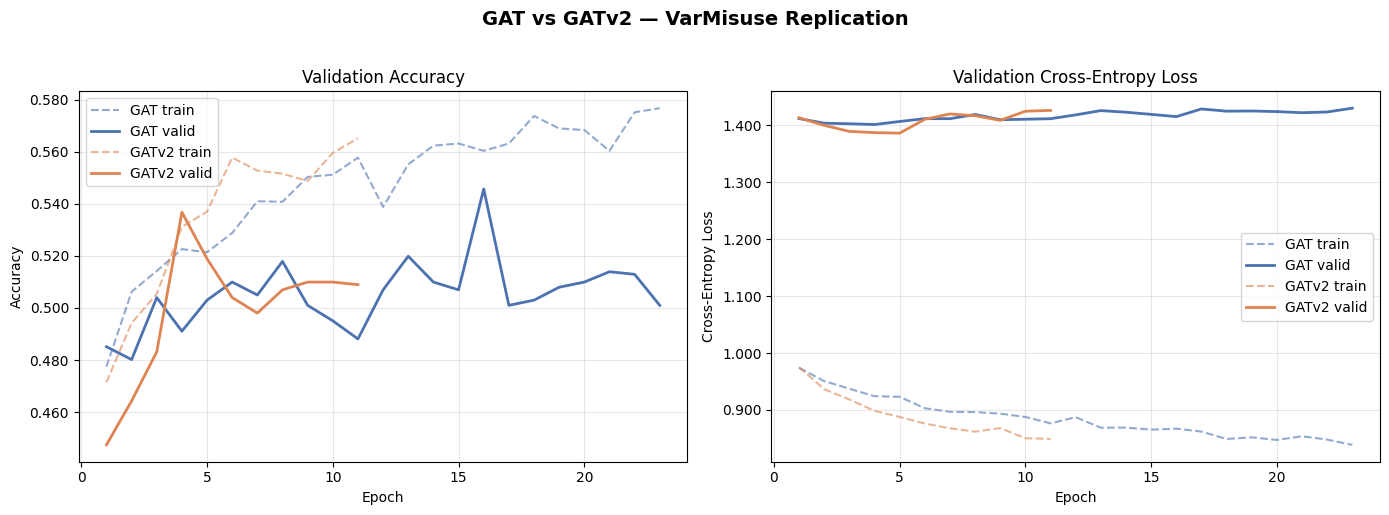

📊 Learning curves saved to varmisuse_curves.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GAT vs GATv2 — VarMisuse Replication', fontsize=14, fontweight='bold', y=1.02)

colors = {'GAT': ('#4C72B0', '#4C72B0'), 'GATv2': ('#DD8452', '#DD8452')}

for ax, metric, ylabel in zip(
    axes, ['acc', 'loss'], ['Accuracy', 'Cross-Entropy Loss']
):
    for model_name, history in [('GAT', gat_history), ('GATv2', gatv2_history)]:
        c = colors[model_name][0]
        epochs = range(1, len(history[f'train_{metric}']) + 1)
        ax.plot(
            epochs, history[f'train_{metric}'],
            linestyle='--', color=c, alpha=0.6, label=f'{model_name} train'
        )
        ax.plot(
            epochs, history[f'valid_{metric}'],
            linestyle='-', color=c, linewidth=2, label=f'{model_name} valid'
        )
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(f'Validation {ylabel}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

plt.tight_layout()
plt.savefig('varmisuse_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Learning curves saved to varmisuse_curves.png")

In [18]:
# ─── Summary Table ────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  FINAL RESULTS — VarMisuse (Program Analysis)")
print("="*55)
print(f"  {'Model':<10} {'Best Val Acc':>12} {'Test Acc':>10}")
print("-"*55)
print(f"  {'GAT':<10} {gat_best_val:>12.4f} {gat_test_acc:>10.4f}")
print(f"  {'GATv2':<10} {gatv2_best_val:>12.4f} {gatv2_test_acc:>10.4f}")
print("-"*55)
delta = gatv2_test_acc - gat_test_acc
sign  = '+' if delta >= 0 else ''
print(f"  {'Δ (v2−v1)':<10} {'':>12} {sign}{delta:>9.4f}")
print("="*55)

if gatv2_test_acc > gat_test_acc:
    print("\n  ✅ GATv2 outperforms GAT — consistent with paper.")
elif gatv2_test_acc == gat_test_acc:
    print("\n  ⚠️  Models tied — consider larger dataset or more epochs.")
else:
    print("\n  ⚠️  GAT outperforms GATv2 — check hyperparameters and subset size.")


  FINAL RESULTS — VarMisuse (Program Analysis)
  Model      Best Val Acc   Test Acc
-------------------------------------------------------
  GAT              0.5456     0.5972
  GATv2            0.5367     0.6071
-------------------------------------------------------
  Δ (v2−v1)               +   0.0099

  ✅ GATv2 outperforms GAT — consistent with paper.
